In [9]:
# =============================================================================
# Bayesian Robust Multivariate Analysis with R2D2 Priors
# Hybrid Fixed/Random Effects Model — Stratified-Responder Simulation
# =============================================================================
#
# DESIGN
#   60 subjects × 25 items × 2 timepoints (Pre/Post) × 2 groups (Active/Control)
#   Long format: 60 × 25 × 2 = 3,000 observations.
#
# DATA-GENERATING PROCESS (NEW)
#   The treatment effect is sparse AND stratum-specific:
#     • Items Y01–Y05 : Active responders only       (Active +5 at Post)
#     • Items Y06–Y08 : Control responders only      (Control +5 at Post)
#     • Items Y09–Y10 : Common time effect, both     (everyone +3 at Post)
#     • Items Y11–Y25 : True nulls (no effect)
#   Plus a small global Pre→Post drift of +1 for every item, every group.
#
#   This setup means:
#     • The difference-of-differences (Active vs Control × Post-Pre) should
#       light up Y01–Y05 (positive ~+5), Y06–Y08 (negative ~-5), and shrink
#       Y09–Y25 toward zero.
#     • Within-treatment Pre→Post contrasts behave differently per stratum.
#     • This is exactly the kind of structure R2D2 is designed to recover.
#
# MODEL
#   Continuous_Score ~ Time * Item + Treatment * Item +
#                      (1 + Time | Subject) +
#                      (0 + Time:Treatment | Item)
#     • Each item has its own fixed Time and Treatment main effects
#       (regularized by R2D2).
#     • Item-specific Time:Treatment interactions are partially pooled across
#       items — adaptive shrinkage on the scientifically interesting params.
#     • Student-t likelihood for outlier robustness.
# =============================================================================



In [10]:

# ---- 0. Setup ---------------------------------------------------------------

suppressPackageStartupMessages({
  library(dplyr)
  library(tidyr)
  library(ggplot2)
  library(brms)
  library(cmdstanr)
  library(tidybayes)
  library(emmeans)
  library(bayesplot)
  library(posterior)
})

set.seed(123)
dir.create("fits", showWarnings = FALSE)

# Sum-to-zero contrasts: critical for R2D2 + interaction models.
# Decorrelates main effects from interactions and dramatically improves HMC
# geometry. Without this, you will see far more divergences and worse ESS.
options(contrasts = c("contr.sum", "contr.poly"))



Warning message:
“package ‘emmeans’ was built under R version 4.5.3”
Warning message:
“package ‘bayesplot’ was built under R version 4.5.2”
Warning message:
“package ‘posterior’ was built under R version 4.5.3”


In [19]:
set_cmdstan_path("/exports/para-lipg-hpc/mdmanurung/cmdstan-2.38.0")

CmdStan path set to: /exports/para-lipg-hpc/mdmanurung/cmdstan-2.38.0



In [20]:

# ---- 1. Simulate data with stratified responders ----------------------------

n_subjects <- 60
n_items    <- 25

subjects <- data.frame(
  Subject        = paste0("S", sprintf("%02d", 1:n_subjects)),
  Treatment      = rep(c("Control", "Active"), each = n_subjects / 2),
  Subj_Intercept = rnorm(n_subjects, mean = 0, sd = 2)
)

items <- data.frame(
  Item           = paste0("Y", sprintf("%02d", 1:n_items)),
  Item_Intercept = rnorm(n_items, mean = 50, sd = 8)
)

# Stratum membership for the DGP — keep these labels for diagnostics later.
active_responders  <- paste0("Y", sprintf("%02d", 1:5))    # Y01–Y05
control_responders <- paste0("Y", sprintf("%02d", 6:8))    # Y06–Y08
common_responders  <- paste0("Y", sprintf("%02d", 9:10))   # Y09–Y10
# Y11–Y25 are nulls

stratum_lookup <- tibble(
  Item = items$Item,
  Stratum = case_when(
    Item %in% active_responders  ~ "Active-only responder",
    Item %in% control_responders ~ "Control-only responder",
    Item %in% common_responders  ~ "Common time effect",
    TRUE                         ~ "Null"
  ),
  # True interaction effect = (Post-Pre|Active) - (Post-Pre|Control)
  true_DoD = case_when(
    Item %in% active_responders  ~  5,
    Item %in% control_responders ~ -5,
    TRUE                         ~  0
  )
)

sim_data <- expand.grid(
  Subject = subjects$Subject,
  Time    = factor(c("Pre", "Post"), levels = c("Pre", "Post")),
  Item    = items$Item
) |>
  left_join(subjects, by = "Subject") |>
  left_join(items,    by = "Item") |>
  mutate(
    # Global drift: everyone gains 1 point at Post (universal time effect)
    Global_Time = ifelse(Time == "Post", 1, 0),

    # Active-only responders: +5 boost in Active group at Post
    Active_Boost = ifelse(
      Time == "Post" & Treatment == "Active" & Item %in% active_responders,
      5, 0
    ),

    # Control-only responders: +5 boost in Control group at Post
    Control_Boost = ifelse(
      Time == "Post" & Treatment == "Control" & Item %in% control_responders,
      5, 0
    ),

    # Common time effect: +3 at Post for both groups
    Common_Boost = ifelse(
      Time == "Post" & Item %in% common_responders,
      3, 0
    ),

    Error = rnorm(n(), mean = 0, sd = 4),

    Continuous_Score =
      Item_Intercept + Subj_Intercept +
      Global_Time + Active_Boost + Control_Boost + Common_Boost + Error
  )

# Analysis-ready long-format data with proper factor coding
data_long_t <- sim_data |>
  transmute(
    Subject          = factor(Subject),
    Treatment        = factor(Treatment, levels = c("Control", "Active")),
    Time             = factor(Time,      levels = c("Pre", "Post")),
    Item             = factor(Item,      levels = items$Item),
    Continuous_Score = Continuous_Score
  )

cat("Data dimensions:", dim(data_long_t), "\n")
cat("\nSubjects per treatment:\n")
print(table(unique(data_long_t[, c("Subject", "Treatment")])$Treatment))
cat("\nResponder strata:\n")
print(stratum_lookup |> count(Stratum, true_DoD))

# Quick sanity check: empirical mean differences per item (raw, no model)
empirical_check <- data_long_t |>
  group_by(Item, Treatment, Time) |>
  summarise(mean_Y = mean(Continuous_Score), .groups = "drop") |>
  pivot_wider(names_from = c(Treatment, Time), values_from = mean_Y) |>
  mutate(
    Active_change  = Active_Post  - Active_Pre,
    Control_change = Control_Post - Control_Pre,
    DoD_empirical  = Active_change - Control_change
  ) |>
  left_join(stratum_lookup, by = "Item") |>
  select(Item, Stratum, true_DoD, DoD_empirical, Active_change, Control_change)

cat("\nEmpirical sanity check (no model — raw means):\n")
print(empirical_check, n = 25)



Data dimensions: 3000 5 

Subjects per treatment:

Control  Active 
     30      30 

Responder strata:


# A tibble: 4 × 3
  Stratum                true_DoD     n
  <chr>                     <dbl> <int>
1 Active-only responder         5     5
2 Common time effect            0     2
3 Control-only responder       -5     3
4 Null                          0    15

Empirical sanity check (no model — raw means):
# A tibble: 25 × 6
   Item  Stratum             true_DoD DoD_empirical Active_change Control_change
   <chr> <chr>                  <dbl>         <dbl>         <dbl>          <dbl>
 1 Y01   Active-only respon…        5         6.63         6.53          -0.104 
 2 Y02   Active-only respon…        5         3.93         5.31           1.38  
 3 Y03   Active-only respon…        5         6.52         6.25          -0.265 
 4 Y04   Active-only respon…        5         4.96         5.11           0.149 
 5 Y05   Active-only respon…        5         4.82         5.01           0.194 
 6 Y06   Control-only respo…       -5        -7.81        -0.509          7.30  
 7 Y07   Control-only respo

In [21]:

# ---- 2. Model specification -------------------------------------------------

formula_hybrid <- bf(
  Continuous_Score ~ Time * Item + Treatment * Item +
    (1 + Time | Subject) +
    (0 + Time:Treatment | Item)
)

# Inspect the prior structure brms generates by default
get_prior(formula_hybrid, data = data_long_t, family = student())



prior,class,coef,group,resp,dpar,nlpar,lb,ub,tag,source
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
,b,,,,,,,,,default
,b,Item1,,,,,,,,default
,b,Item1:Treatment1,,,,,,,,default
,b,Item10,,,,,,,,default
,b,Item10:Treatment1,,,,,,,,default
,b,Item11,,,,,,,,default
,b,Item11:Treatment1,,,,,,,,default
,b,Item12,,,,,,,,default
,b,Item12:Treatment1,,,,,,,,default


In [22]:

# ---- 3. Priors --------------------------------------------------------------
#
# R2D2 hyperparameters
#   mean_R2 = 0.4 — moderate prior expectation of variance explained.
#                   Tune up if real data are more strongly structured.
#   prec_R2 = 2   — moderately informative concentration around mean_R2.
#                   Higher (e.g., 4) tightens the prior on R²; tighter R²
#                   often resolves residual divergences.
#   cons_D  = 0.5 — Dirichlet concentration. <1 favors sparsity (a few
#                   coefficients carry most variance), =1 is uniform on the
#                   simplex, >1 is anti-sparse. Tune lower (0.1–0.3) for
#                   aggressive selection.

priors_hybrid <- c(
  prior(R2D2(mean_R2 = 0.4, prec_R2 = 2, cons_D = 0.5), class = "b"),
  prior(student_t(3, 0, 10), class = "Intercept"),
  prior(student_t(3, 0, 5),  class = "sigma"),
  prior(gamma(2, 0.1),       class = "nu"),
  prior(student_t(3, 0, 5),  class = "sd"),
  prior(lkj(2),              class = "cor")
)



In [23]:

# ---- 4. Fit the model -------------------------------------------------------
#
# Control settings
#   adapt_delta   = 0.99 — high; R2D2 + interactions create challenging geometry.
#   max_treedepth = 12   — modest bump from default 10.
#   init          = 0.1  — initialize parameters in [-0.1, 0.1] uniformly
#                          (default is [-2, 2]). R2D2's Dirichlet structure can
#                          land in pathological corners with diffuse inits.
#   iter / warmup        — longer warmup helps R2D2's hierarchical adaptation.
#
# Caching: file_refit = "on_change" forces a refit whenever the formula, data,
# priors, or family change. Without this, edits to the script could silently
# load a stale fit.

fit_hybrid <- brm(
  formula = formula_hybrid,
  data    = data_long_t,
  family  = student(),
  prior   = priors_hybrid,
  backend = "cmdstanr",
  chains  = 4,
  cores   = 4,
  iter    = 4000,
  warmup  = 2000,
  init    = 0.1,
  control = list(
    adapt_delta   = 0.99,
    max_treedepth = 12
  ),
  seed    = 123,
  refresh = 200
)


ar: creating stan/lib/stan_math/lib/sundials_6.1.1/lib/libsundials_nvecserial.a


ar: creating stan/lib/stan_math/lib/sundials_6.1.1/lib/libsundials_cvodes.a


ar: creating stan/lib/stan_math/lib/sundials_6.1.1/lib/libsundials_idas.a


ar: creating stan/lib/stan_math/lib/sundials_6.1.1/lib/libsundials_kinsol.a


/exports/para-lipg-hpc/mdmanurung/cmdstan-2.38.0/stan/lib/stan_math/lib/tbb_2020.3/build/Makefile.tbb:28: CONFIG: cfg=release arch=intel64 compiler=gcc target=linux runtime=cc8.5.0_libc2.28_kernel4.18.0


Start sampling



Running MCMC with 4 parallel chains...

Chain 1 Iteration:    1 / 4000 [  0%]  (Warmup) 
Chain 2 Iteration:    1 / 4000 [  0%]  (Warmup) 
Chain 3 Iteration:    1 / 4000 [  0%]  (Warmup) 
Chain 4 Iteration:    1 / 4000 [  0%]  (Warmup) 
Chain 2 Iteration:  200 / 4000 [  5%]  (Warmup) 
Chain 3 Iteration:  200 / 4000 [  5%]  (Warmup) 
Chain 4 Iteration:  200 / 4000 [  5%]  (Warmup) 
Chain 2 Iteration:  400 / 4000 [ 10%]  (Warmup) 
Chain 3 Iteration:  400 / 4000 [ 10%]  (Warmup) 
Chain 2 Iteration:  600 / 4000 [ 15%]  (Warmup) 
Chain 1 Iteration:  200 / 4000 [  5%]  (Warmup) 
Chain 4 Iteration:  400 / 4000 [ 10%]  (Warmup) 
Chain 3 Iteration:  600 / 4000 [ 15%]  (Warmup) 
Chain 3 Iteration:  800 / 4000 [ 20%]  (Warmup) 
Chain 2 Iteration:  800 / 4000 [ 20%]  (Warmup) 
Chain 4 Iteration:  600 / 4000 [ 15%]  (Warmup) 
Chain 3 Iteration: 1000 / 4000 [ 25%]  (Warmup) 
Chain 1 Iteration:  400 / 4000 [ 10%]  (Warmup) 
Chain 2 Iteration: 1000 / 4000 [ 25%]  (Warmup) 
Chain 4 Iteration:  800 / 400

Loading required namespace: rstan



 Family: student 
  Links: mu = identity 
Formula: Continuous_Score ~ Time * Item + Treatment * Item + (1 + Time | Subject) + (0 + Time:Treatment | Item) 
   Data: data_long_t (Number of observations: 3000) 
  Draws: 4 chains, each with iter = 4000; warmup = 2000; thin = 1;
         total post-warmup draws = 8000

Multilevel Hyperparameters:
~Item (Number of levels: 25) 
                                                        Estimate Est.Error
sd(TimePre:TreatmentControl)                               7.231     0.773
sd(TimePost:TreatmentControl)                              7.342     0.786
sd(TimePre:TreatmentActive)                                7.204     0.767
sd(TimePost:TreatmentActive)                               7.090     0.770
cor(TimePre:TreatmentControl,TimePost:TreatmentControl)    0.939     0.029
cor(TimePre:TreatmentControl,TimePre:TreatmentActive)      0.983     0.011
cor(TimePost:TreatmentControl,TimePre:TreatmentActive)     0.965     0.020
cor(TimePre:TreatmentContr

Using all posterior draws for ppc type 'stat_grouped' by default.

Note: in most cases the default test statistic 'mean' is too weak to detect anything of interest.

`stat_bin()` using `bins = 30`. Pick better value `binwidth`.


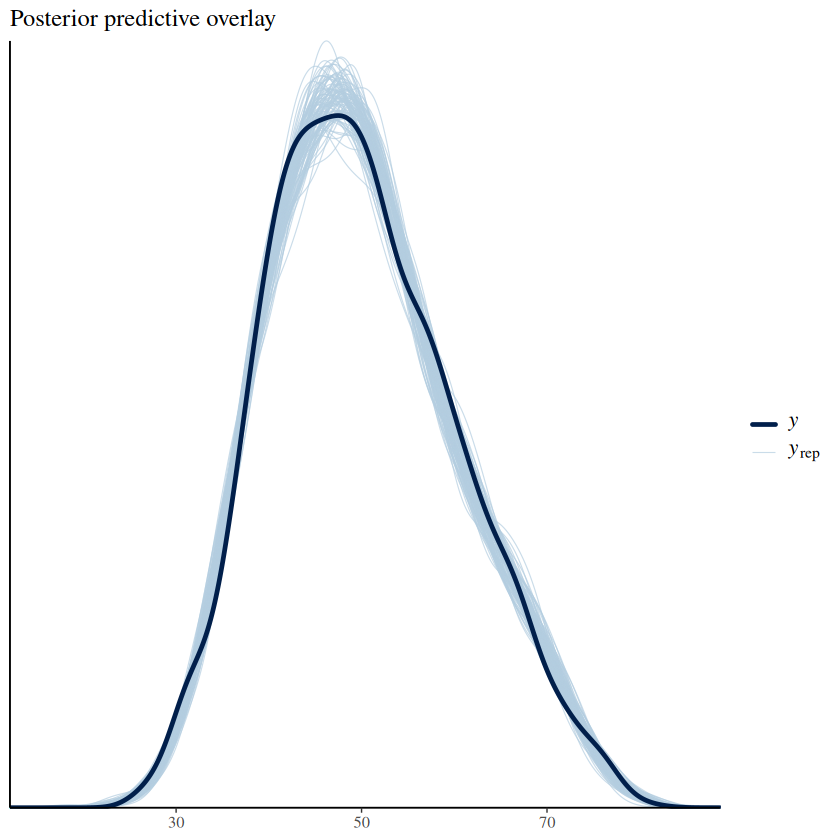

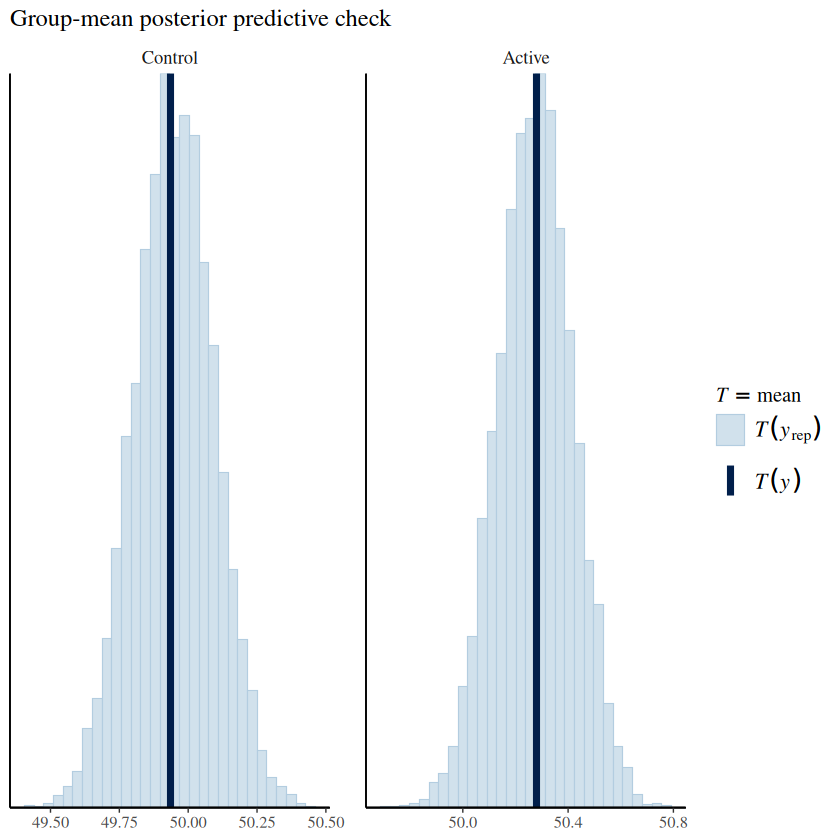

In [24]:


# ---- 5. Convergence diagnostics ---------------------------------------------

print(summary(fit_hybrid), digits = 3)

# NUTS-level diagnostics
np <- nuts_params(fit_hybrid)

n_div <- sum(subset(np, Parameter == "divergent__")$Value)
n_td  <- sum(subset(np, Parameter == "treedepth__")$Value >= 12)
cat("\nDivergent transitions:", n_div, "\n")
cat("Max treedepth hits:    ", n_td, "\n")

# Quick Rhat/ESS summary across all parameters
rhat_summary <- rhat(fit_hybrid)
ess_summary  <- neff_ratio(fit_hybrid)
cat("Max Rhat:           ", round(max(rhat_summary, na.rm = TRUE), 4), "\n")
cat("Min ESS ratio (bulk):", round(min(ess_summary, na.rm = TRUE), 3), "\n")

# Posterior predictive checks
pp_check(fit_hybrid, ndraws = 100) +
  ggtitle("Posterior predictive overlay")
pp_check(fit_hybrid, type = "stat_grouped",
         group = "Treatment", stat = "mean") +
  ggtitle("Group-mean posterior predictive check")

# If divergences > ~10 / 8000 post-warmup draws:
#   1. Raise adapt_delta to 0.995.
#   2. Tighten R2D2 prior: prec_R2 = 4.
#   3. Diagnose with pair plots:
#        mcmc_pairs(fit_hybrid, np = np,
#                   pars = c("sigma", "nu",
#                            "sd_Item__TimePost:TreatmentActive"))



In [25]:

# ---- 6. Item-level treatment-effect-on-change (difference-of-differences) ---
#
# Quantity: [Post-Pre | Active] - [Post-Pre | Control], per Item.
# This is the population-level Time:Treatment interaction for each item, the
# scientifically meaningful quantity for "did treatment cause a change?"
#
# CRITICAL: re_formula = NULL tells emmeans to integrate over ALL random
# effects, including (Time:Treatment | Item). Without this, emmeans conditions
# on random effects = 0, which would *exclude* the item-specific interaction
# variation that's the whole point of the hybrid model.

emm_grid <- emmeans(
  fit_hybrid,
  ~ Time * Treatment | Item,
  re_formula = NULL,
  nesting    = NULL
)

dod_contrasts <- contrast(
  emm_grid,
  interaction = c(Time = "revpairwise", Treatment = "revpairwise"),
  by = "Item"
)

# Pull tidy posterior draws (preserves .draw for downstream joins)
dod_draws <- gather_emmeans_draws(dod_contrasts)

# Per-item summaries
dod_summary <- dod_draws |>
  group_by(Item) |>
  summarise(
    median      = median(.value),
    lower_95    = quantile(.value, 0.025),
    upper_95    = quantile(.value, 0.975),
    p_positive  = mean(.value > 0),
    p_direction = pmax(mean(.value > 0), mean(.value < 0)),
    .groups     = "drop"
  ) |>
  left_join(stratum_lookup, by = "Item") |>
  arrange(desc(median))

cat("\nDifference-of-differences by item (posterior summary):\n")
print(dod_summary, n = 25)




Difference-of-differences by item (posterior summary):
# A tibble: 25 × 8
   Item   median lower_95 upper_95 p_positive p_direction Stratum       true_DoD
   <chr>   <dbl>    <dbl>    <dbl>      <dbl>       <dbl> <chr>            <dbl>
 1 Y03    5.99      3.43     8.65    1              1     Active-only …        5
 2 Y01    5.89      3.29     8.58    1              1     Active-only …        5
 3 Y04    4.84      2.31     7.41    1              1     Active-only …        5
 4 Y05    4.28      1.63     6.91    0.999          0.999 Active-only …        5
 5 Y02    4.08      1.50     6.69    0.999          0.999 Active-only …        5
 6 Y22    2.34     -0.268    4.95    0.964          0.964 Null                 0
 7 Y25    2.16     -0.525    4.89    0.942          0.942 Null                 0
 8 Y12    1.32     -1.22     3.92    0.847          0.847 Null                 0
 9 Y11    0.882    -1.71     3.44    0.755          0.755 Null                 0
10 Y14    0.736    -1.82     3.27 

In [26]:

# ---- 7. Within-treatment Pre→Post contrasts --------------------------------

prepost_by_treatment <- emmeans(
  fit_hybrid,
  ~ Time | Treatment * Item,
  re_formula = NULL,
  nesting    = NULL
) |>
  contrast(method = "revpairwise", by = c("Treatment", "Item")) |>
  gather_emmeans_draws() |>
  group_by(Treatment, Item) |>
  summarise(
    median   = median(.value),
    lower_95 = quantile(.value, 0.025),
    upper_95 = quantile(.value, 0.975),
    .groups  = "drop"
  ) |>
  left_join(stratum_lookup, by = "Item")

cat("\nWithin-treatment Pre→Post contrasts:\n")
print(prepost_by_treatment, n = 50)



Within-treatment Pre→Post contrasts:
# A tibble: 50 × 7
   Treatment Item   median lower_95 upper_95 Stratum                true_DoD
   <fct>     <chr>   <dbl>    <dbl>    <dbl> <chr>                     <dbl>
 1 Control   Y01   -0.0909   -1.95      1.73 Active-only responder         5
 2 Control   Y02    1.04     -0.759     2.88 Active-only responder         5
 3 Control   Y03   -0.274    -2.10      1.50 Active-only responder         5
 4 Control   Y04    0.0519   -1.75      1.86 Active-only responder         5
 5 Control   Y05    0.341    -1.48      2.21 Active-only responder         5
 6 Control   Y06    6.41      4.51      8.34 Control-only responder       -5
 7 Control   Y07    4.59      2.77      6.52 Control-only responder       -5
 8 Control   Y08    5.39      3.59      7.29 Control-only responder       -5
 9 Control   Y09    3.22      1.41      5.07 Common time effect            0
10 Control   Y10    2.94      1.10      4.84 Common time effect            0
11 Control   Y11   

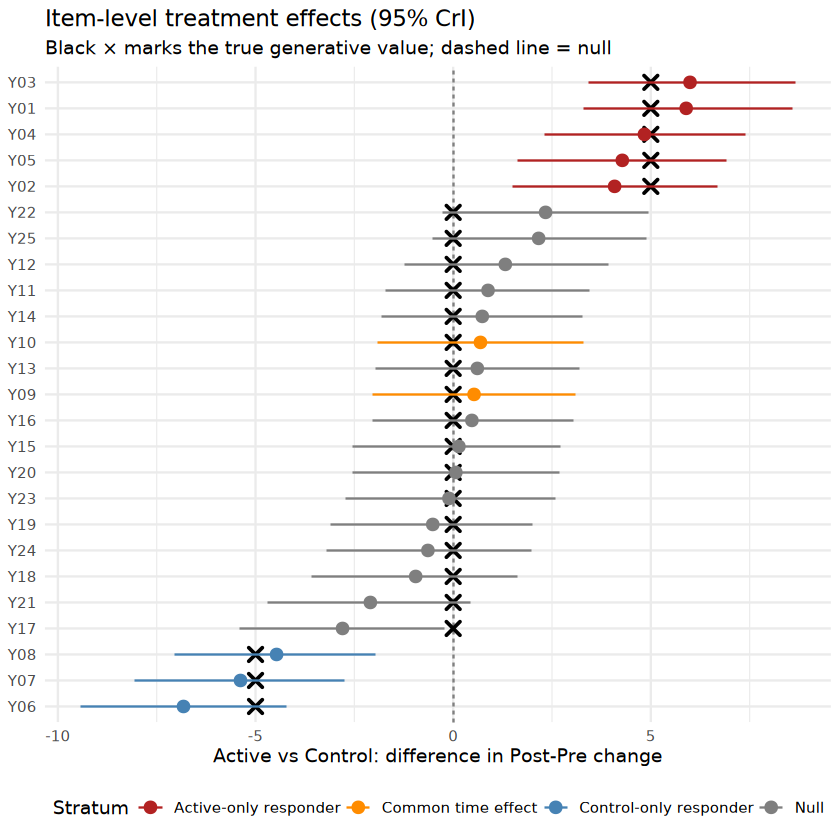

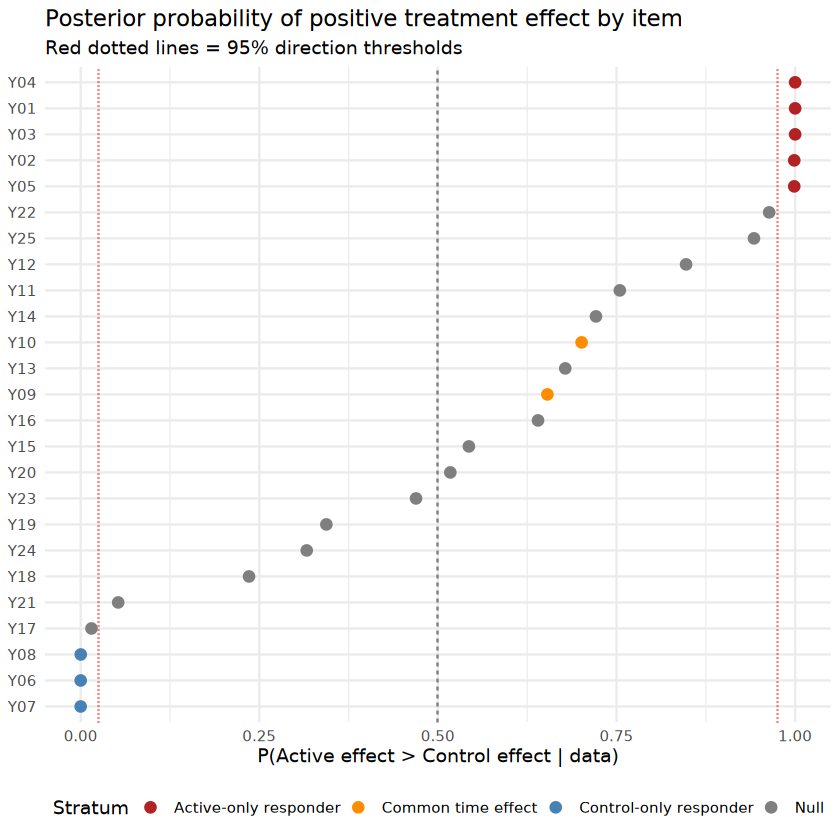

In [27]:


# ---- 8. Visualization -------------------------------------------------------

# 8a. Forest plot of difference-of-differences, colored by true stratum
stratum_colors <- c(
  "Active-only responder"  = "firebrick",
  "Control-only responder" = "steelblue",
  "Common time effect"     = "darkorange",
  "Null"                   = "grey50"
)

p_forest <- dod_summary |>
  mutate(Item = factor(Item, levels = Item[order(median)])) |>
  ggplot(aes(x = median, y = Item, color = Stratum)) +
  geom_vline(xintercept = 0, linetype = "dashed", color = "grey50") +
  # Mark each item's true generative DoD value
  geom_point(aes(x = true_DoD), shape = 4, size = 3, stroke = 1.2,
             color = "black", show.legend = FALSE) +
  geom_pointrange(aes(xmin = lower_95, xmax = upper_95)) +
  scale_color_manual(values = stratum_colors) +
  labs(
    x = "Active vs Control: difference in Post-Pre change",
    y = NULL,
    title = "Item-level treatment effects (95% CrI)",
    subtitle = "Black × marks the true generative value; dashed line = null"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

print(p_forest)
ggsave("fits/forest_dod_v2.png", p_forest, width = 8, height = 8, dpi = 150)

# 8b. Posterior probability of direction
p_pdir <- dod_summary |>
  mutate(Item = factor(Item, levels = Item[order(p_positive)])) |>
  ggplot(aes(x = p_positive, y = Item, color = Stratum)) +
  geom_vline(xintercept = c(0.025, 0.5, 0.975),
             linetype = c("dotted", "dashed", "dotted"),
             color = c("red", "grey50", "red")) +
  geom_point(size = 2.5) +
  scale_x_continuous(limits = c(0, 1), breaks = seq(0, 1, 0.25)) +
  scale_color_manual(values = stratum_colors) +
  labs(
    x = "P(Active effect > Control effect | data)",
    y = NULL,
    title = "Posterior probability of positive treatment effect by item",
    subtitle = "Red dotted lines = 95% direction thresholds"
  ) +
  theme_minimal() +
  theme(legend.position = "bottom")

print(p_pdir)
ggsave("fits/pdir_v2.png", p_pdir, width = 8, height = 8, dpi = 150)



In [28]:

# ---- 9. Standardized effect sizes ------------------------------------------
#
# Express each item's interaction effect in residual-SD units (Cohen's d-like).
# Useful for cross-item comparison and reporting.

sigma_draws <- fit_hybrid |>
  spread_draws(sigma) |>
  ungroup() |>
  select(.draw, sigma)

dod_standardized <- dod_draws |>
  ungroup() |>
  left_join(sigma_draws, by = ".draw") |>
  mutate(d = .value / sigma) |>
  group_by(Item) |>
  summarise(
    d_median   = median(d),
    d_lower_95 = quantile(d, 0.025),
    d_upper_95 = quantile(d, 0.975),
    .groups    = "drop"
  ) |>
  left_join(stratum_lookup, by = "Item") |>
  arrange(desc(d_median))

cat("\nStandardized effect sizes (d-like):\n")
print(dod_standardized, n = 25)




Standardized effect sizes (d-like):
# A tibble: 25 × 6
   Item  d_median d_lower_95 d_upper_95 Stratum                true_DoD
   <chr>    <dbl>      <dbl>      <dbl> <chr>                     <dbl>
 1 Y03     1.54       0.886      2.23   Active-only responder         5
 2 Y01     1.52       0.848      2.20   Active-only responder         5
 3 Y04     1.24       0.591      1.90   Active-only responder         5
 4 Y05     1.10       0.412      1.77   Active-only responder         5
 5 Y02     1.05       0.385      1.72   Active-only responder         5
 6 Y22     0.601     -0.0679     1.28   Null                          0
 7 Y25     0.554     -0.133      1.26   Null                          0
 8 Y12     0.339     -0.312      1.01   Null                          0
 9 Y11     0.228     -0.439      0.888  Null                          0
10 Y14     0.189     -0.467      0.842  Null                          0
11 Y10     0.177     -0.485      0.852  Common time effect            0
12 Y13  

In [29]:

# ---- 10. Selection performance summary -------------------------------------
#
# Treat this as a binary selection problem with a 95% CrI rule, and compute
# the resulting confusion matrix vs. the known truth.

selection <- dod_summary |>
  mutate(
    decision = case_when(
      lower_95 > 0  ~ "Positive responder",
      upper_95 < 0  ~ "Negative responder",
      TRUE          ~ "Null"
    ),
    truth = case_when(
      true_DoD > 0  ~ "Positive responder",
      true_DoD < 0  ~ "Negative responder",
      TRUE          ~ "Null"
    )
  )

cat("\nSelection confusion matrix (95% CrI rule):\n")
print(table(Truth = selection$truth, Decision = selection$decision))




Selection confusion matrix (95% CrI rule):
                    Decision
Truth                Negative responder Null Positive responder
  Negative responder                  3    0                  0
  Null                                1   16                  0
  Positive responder                  0    0                  5


In [30]:

# ---- 11. Marginal R² and shrinkage diagnostics -----------------------------

cat("\nBayes R²:\n")
print(bayes_R2(fit_hybrid))

# The realized R²-prior parameter is exposed by brms as 'R2D2' (no suffix).
# We pull it via `as_draws_df` to be robust to brms' internal naming.
r2d2_draws <- as_draws_df(fit_hybrid) |>
  as.data.frame() |>
  select(starts_with("R2D2"), -tidyselect::any_of(c("R2D2_phi"))) |>
  select(where(is.numeric))

if (ncol(r2d2_draws) > 0) {
  cat("\nRealized R2D2 R² posterior summary:\n")
  print(summary(r2d2_draws[[1]]))
}




Bayes R²:
    Estimate   Est.Error      Q2.5     Q97.5
R2 0.8442756 0.002247206 0.8397295 0.8485566

Realized R2D2 R² posterior summary:
   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
0.01723 0.17512 0.24387 0.25821 0.32860 0.75388 


In [31]:

# =============================================================================
# 12. AUDIT: Does the model recover the truth?
# =============================================================================
#
# Three checks:
#   (a) Calibration: do 95% CrIs cover their true values at ~95% rate?
#   (b) Type-I behavior: how shrunk are the 15 null items?
#   (c) Power: how many true non-null items did we recover?

audit <- dod_summary |>
  mutate(
    covers_truth = (true_DoD >= lower_95) & (true_DoD <= upper_95),
    width_95     = upper_95 - lower_95
  )

cat("\nCalibration (CrI coverage of true value):\n")
audit |>
  group_by(Stratum) |>
  summarise(
    n          = n(),
    coverage   = mean(covers_truth),
    mean_width = mean(width_95),
    .groups    = "drop"
  ) |>
  print()

cat("\nNull-item shrinkage (how close to 0 are the null estimates?):\n")
audit |>
  filter(Stratum == "Null") |>
  summarise(
    n             = n(),
    mean_estimate = mean(median),
    sd_estimate   = sd(median),
    max_abs       = max(abs(median))
  ) |>
  print()

cat("\nResponder recovery (recovered estimate vs truth):\n")
audit |>
  filter(Stratum != "Null") |>
  select(Item, Stratum, true_DoD, median, lower_95, upper_95, covers_truth) |>
  print()


# =============================================================================
# End of script
# =============================================================================


Calibration (CrI coverage of true value):
# A tibble: 4 × 4
  Stratum                    n coverage mean_width
  <chr>                  <int>    <dbl>      <dbl>
1 Active-only responder      5    1           5.22
2 Common time effect         2    1           5.17
3 Control-only responder     3    1           5.21
4 Null                      15    0.933       5.19

Null-item shrinkage (how close to 0 are the null estimates?):
# A tibble: 1 × 4
      n mean_estimate sd_estimate max_abs
  <int>         <dbl>       <dbl>   <dbl>
1    15         0.109        1.40    2.80

Responder recovery (recovered estimate vs truth):
# A tibble: 10 × 7
   Item  Stratum                true_DoD median lower_95 upper_95 covers_truth
   <chr> <chr>                     <dbl>  <dbl>    <dbl>    <dbl> <lgl>       
 1 Y03   Active-only responder         5  5.99      3.43     8.65 TRUE        
 2 Y01   Active-only responder         5  5.89      3.29     8.58 TRUE        
 3 Y04   Active-only responder         5